# cbsa_coding.ipynb

This notebook identifies which PUMAs/MIGPUMAs make up a CBSA (core based statistical area) and outputs, for each PUMA/MIGPUMA, a measure of how large its overarching CBSA is (T34, Metro, Micro).

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import shapely.geometry as shp

In [62]:
YEAR = 2018

In [63]:
cbsa = gpd.read_file(f"tl_{YEAR}_us_cbsa/tl_{YEAR}_us_cbsa.shp")

<Axes: >

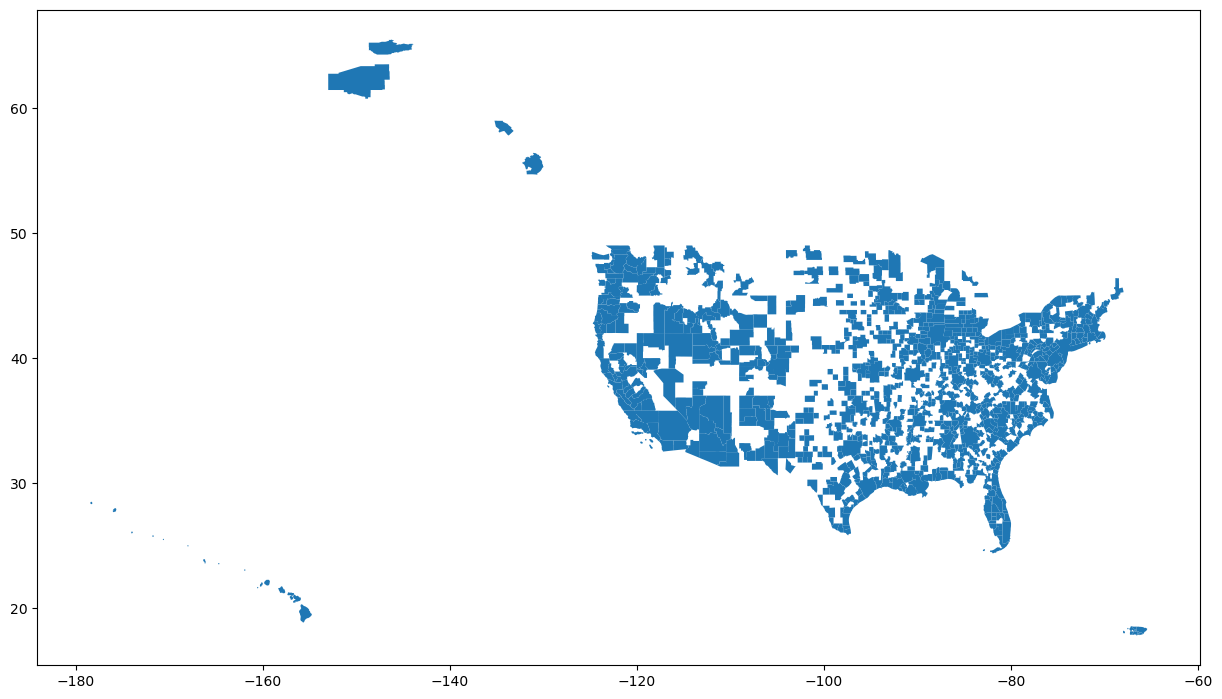

In [64]:
fig, ax = plt.subplots(figsize=(15, 15))
cbsa.plot(ax=ax)

<Axes: >

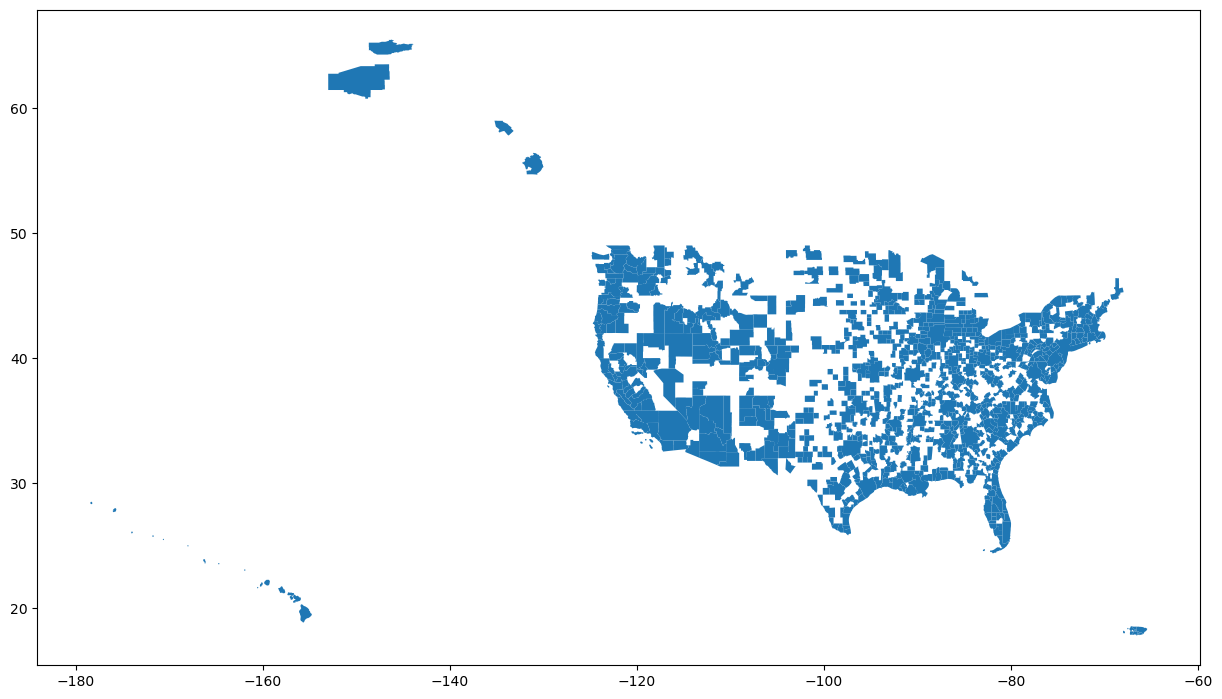

In [65]:
fig, ax = plt.subplots(figsize=(15, 15))
cbsa.plot(ax=ax)

In [66]:
cbsa["NAMELSAD"].str.split().str[-2]

0      Metro
1      Metro
2      Metro
3      Metro
4      Micro
       ...  
940    Micro
941    Micro
942    Micro
943    Micro
944    Micro
Name: NAMELSAD, Length: 945, dtype: object

In [67]:
cbsa["type"] = cbsa["NAMELSAD"].str.split().str[-2]

In [68]:
cbsa["INTPTLAT"] = cbsa["INTPTLAT"].str.strip("+").astype(float)
cbsa["INTPTLON"] = cbsa["INTPTLON"].str.strip("+").astype(float)

In [69]:
cbsa = cbsa.set_index("NAME")

In [70]:
# https://en.wikipedia.org/wiki/List_of_core-based_statistical_areas, greater than 2M
cbsa.loc["New York-Newark-Jersey City, NY-NJ-PA", "type"] = "T34"
cbsa.loc["Los Angeles-Long Beach-Anaheim, CA", "type"] = "T34"
cbsa.loc["Chicago-Naperville-Elgin, IL-IN-WI", "type"] = "T34"
cbsa.loc["Dallas-Fort Worth-Arlington, TX", "type"] = "T34"
cbsa.loc["Houston-The Woodlands-Sugar Land, TX", "type"] = "T34"
cbsa.loc["Washington-Arlington-Alexandria, DC-VA-MD-WV", "type"] = "T34"
cbsa.loc["Miami-Fort Lauderdale-West Palm Beach, FL", "type"] = "T34"
cbsa.loc["Philadelphia-Camden-Wilmington, PA-NJ-DE-MD", "type"] = "T34"
cbsa.loc["Atlanta-Sandy Springs-Roswell, GA", "type"] = "T34"
cbsa.loc["Phoenix-Mesa-Scottsdale, AZ", "type"] = "T34"
cbsa.loc["Boston-Cambridge-Newton, MA-NH", "type"] = "T34"
cbsa.loc["San Francisco-Oakland-Hayward, CA", "type"] = "T34"
cbsa.loc["Riverside-San Bernardino-Ontario, CA", "type"] = "T34"
cbsa.loc["Detroit-Warren-Dearborn, MI", "type"] = "T34"
cbsa.loc["Seattle-Tacoma-Bellevue, WA", "type"] = "T34"
cbsa.loc["Minneapolis-St. Paul-Bloomington, MN-WI", "type"] = "T34"
cbsa.loc["San Diego-Carlsbad, CA", "type"] = "T34"
cbsa.loc["Tampa-St. Petersburg-Clearwater, FL", "type"] = "T34"
cbsa.loc["Denver-Aurora-Lakewood, CO", "type"] = "T34"
cbsa.loc["St. Louis, MO-IL", "type"] = "T34"
cbsa.loc["Baltimore-Columbia-Towson, MD", "type"] = "T34"
cbsa.loc["Charlotte-Concord-Gastonia, NC-SC", "type"] = "T34"
cbsa.loc["Orlando-Kissimmee-Sanford, FL", "type"] = "T34"
cbsa.loc["San Antonio-New Braunfels, TX", "type"] = "T34"
cbsa.loc["Portland-Vancouver-Hillsboro, OR-WA", "type"] = "T34"
cbsa.loc["Sacramento--Roseville--Arden-Arcade, CA", "type"] = "T34"
cbsa.loc["Las Vegas-Henderson-Paradise, NV", "type"] = "T34"
cbsa.loc["Pittsburgh, PA", "type"] = "T34"
cbsa.loc["Austin-Round Rock, TX", "type"] = "T34"
cbsa.loc["Cincinnati, OH-KY-IN", "type"] = "T34"
cbsa.loc["Kansas City, MO-KS", "type"] = "T34"
cbsa.loc["Columbus, OH", "type"] = "T34"
cbsa.loc["Indianapolis-Carmel-Anderson, IN", "type"] = "T34"
cbsa.loc["Cleveland-Elyria, OH", "type"] = "T34"

<Axes: >

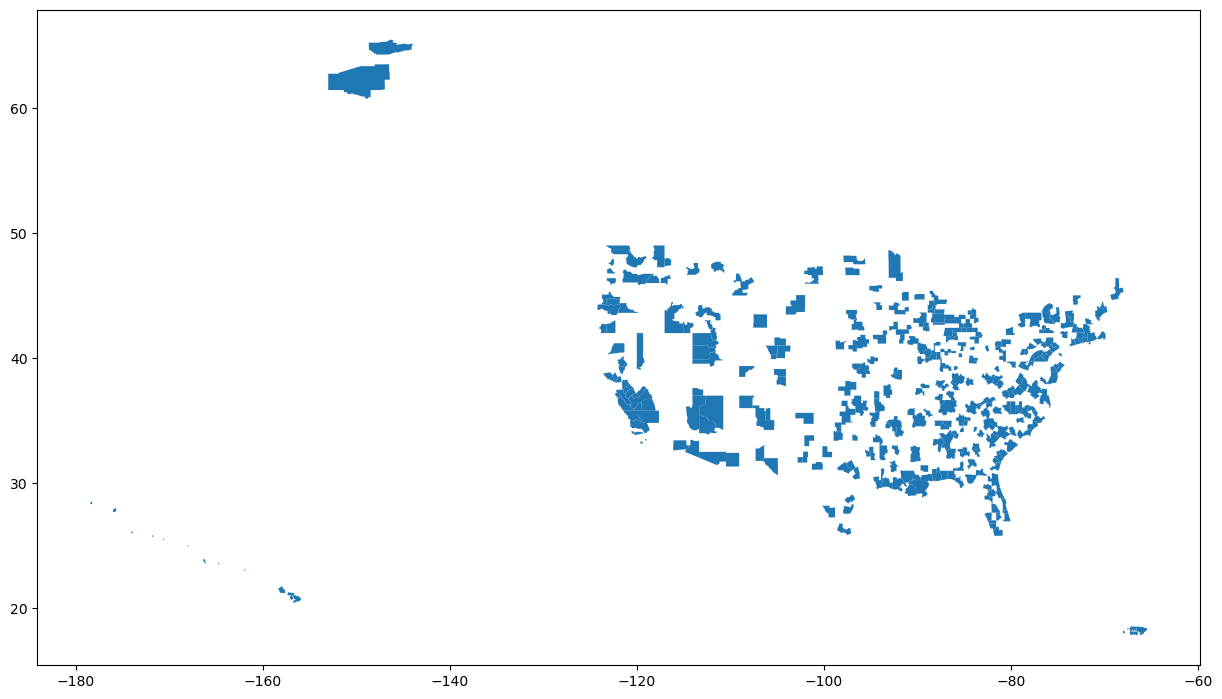

In [71]:
fig, ax = plt.subplots(figsize=(15, 15))
cbsa[cbsa["type"]=="Metro"].plot(ax=ax)

<Axes: >

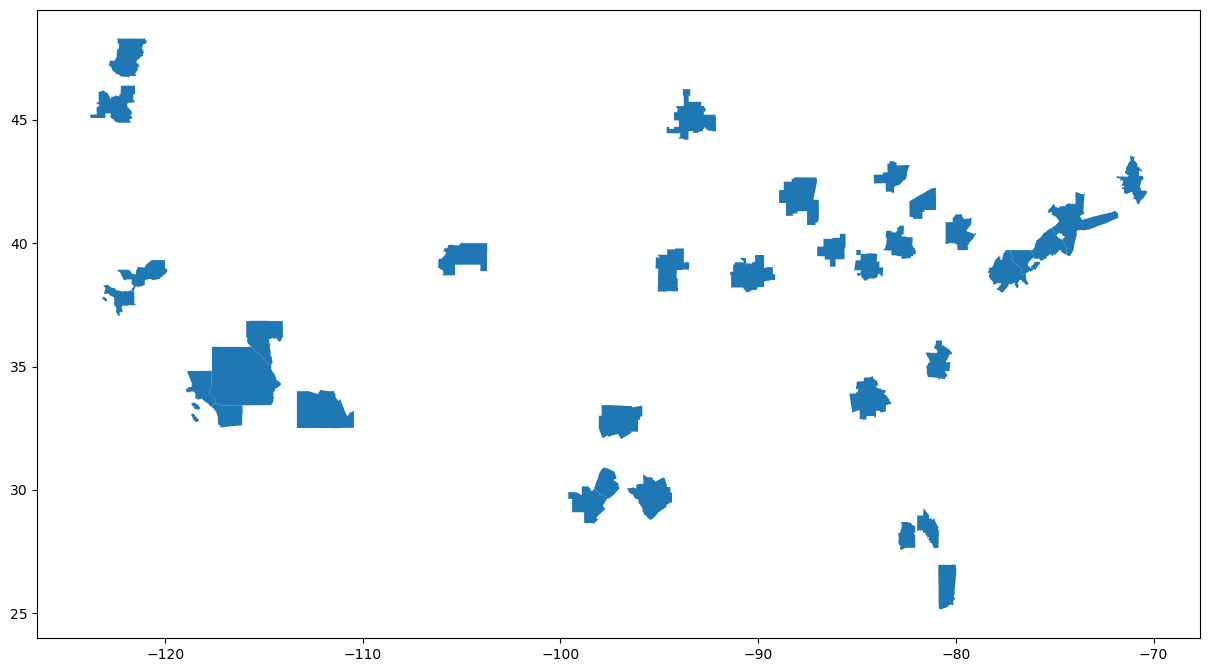

In [72]:
fig, ax = plt.subplots(figsize=(15, 15))
cbsa[cbsa["type"]=="T34"].plot(ax=ax)

In [73]:
us = gpd.read_file("../pumas/ipums_puma_2010.shp")

In [74]:
cbsa = cbsa.to_crs(us.crs)

In [75]:
print(cbsa.crs)
print(us.crs)

PROJCS["USA_Contiguous_Albers_Equal_Area_Conic",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4269"]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude_of_center",37.5],PARAMETER["longitude_of_center",-96],PARAMETER["standard_parallel_1",29.5],PARAMETER["standard_parallel_2",45.5],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["ESRI","102003"]]
PROJCS["USA_Contiguous_Albers_Equal_Area_Conic",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","42

In [76]:
us["center"] = us["geometry"].centroid

In [77]:
# Build a GeoDataFrame of PUMA centers
puma_centers = gpd.GeoDataFrame(
    us.copy(),
    geometry=[shp.Point(c) for c in us["center"]],
    crs=cbsa.crs  # make sure CRS matches cbsa
)

# Spatial join: attach the CBSA polygon that contains each point
joined = gpd.sjoin(
    puma_centers,
    cbsa[["geometry", "type", "NAMELSAD"]],
    how="left",
    predicate="within"
)

# Map results back onto `us`
us["type"] = joined["type"].values
us["CBSA_name"] = joined["NAMELSAD"].values

In [78]:
us["type"].value_counts()

type
T34      1129
Metro     881
Micro     184
Name: count, dtype: int64

In [79]:
us.drop("geometry", axis=1).to_csv(f"puma_density_{YEAR}.csv")

In [80]:
us_migpuma = gpd.read_file("../migpumas/ipums_migpuma_pwpuma_2010.shp")

<Axes: >

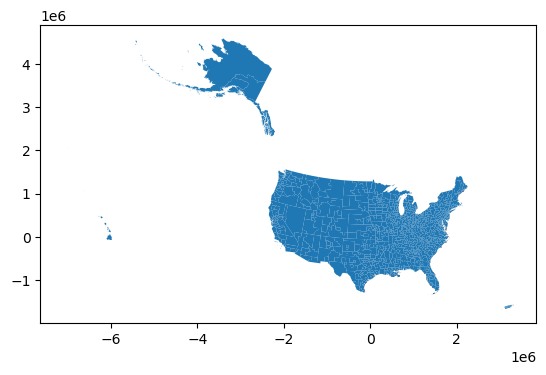

In [81]:
us_migpuma.plot()

In [82]:
us_migpuma.crs

<Projected CRS: ESRI:102003>
Name: USA_Contiguous_Albers_Equal_Area_Conic
Axis Info [cartesian]:
- [east]: Easting (metre)
- [north]: Northing (metre)
Area of Use:
- undefined
Coordinate Operation:
- name: unnamed
- method: Albers Equal Area
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [83]:
cbsa = cbsa.to_crs(us_migpuma.crs)

In [84]:
print(cbsa.crs)
print(us_migpuma.crs)

PROJCS["USA_Contiguous_Albers_Equal_Area_Conic",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4269"]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude_of_center",37.5],PARAMETER["longitude_of_center",-96],PARAMETER["standard_parallel_1",29.5],PARAMETER["standard_parallel_2",45.5],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["ESRI","102003"]]
PROJCS["USA_Contiguous_Albers_Equal_Area_Conic",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","42

In [85]:
us_migpuma["center"] = us_migpuma["geometry"].centroid

In [86]:
# Build a GeoDataFrame of migPUMA centers
migpuma_centers = gpd.GeoDataFrame(
    us_migpuma.copy(),
    geometry=[shp.Point(c) for c in us_migpuma["center"]],
    crs=cbsa.crs  # ensure CRS matches cbsa
)

# Spatial join: attach the CBSA polygon that contains each point
joined = gpd.sjoin(
    migpuma_centers,
    cbsa[["geometry", "type", "NAMELSAD"]],
    how="left",
    predicate="within"
)

# Map results back onto us_migpuma
us_migpuma["type"] = joined["type"].values
us_migpuma["CBSA_name"] = joined["NAMELSAD"].values

In [87]:
us_migpuma

,GISMATCH,STATEFIP,State,MIGPLAC,MIGPUMA,PWSTATE,PWPUMA,geometry,center,type,CBSA_name
0,600100,06,California,006,00100,06,00100,"MULTIPOLYGON (((-2247215.331 305414.315, -2247...",POINT (-2234513.519 322640.238),T34,"San Francisco-Oakland-Hayward, CA Metro Area"
1,600700,06,California,006,00700,06,00700,"POLYGON ((-2109286.066 514980.044, -2109870.85...",POINT (-2150235.361 534214.02),Metro,"Chico, CA Metro Area"
2,601100,06,California,006,01100,06,01100,"POLYGON ((-2176959.324 718143.586, -2176964.76...",POINT (-2216786.261 604917.449),Micro,"Red Bluff, CA Micro Area"
3,601300,06,California,006,01300,06,01300,"MULTIPOLYGON (((-2206584.289 357733.694, -2206...",POINT (-2229879.805 352695.14),T34,"San Francisco-Oakland-Hayward, CA Metro Area"
4,601500,06,California,006,01500,06,01500,"MULTIPOLYGON (((-2293024.796 785731.068, -2293...",POINT (-2096371.82 692307.651),Metro,"Redding, CA Metro Area"
...,...,...,...,...,...,...,...,...,...,...,...
1000,1304007,13,Georgia,013,04007,13,04007,"POLYGON ((1107917.124 -309977.513, 1108009.534...",POINT (1095790.602 -326953.072),T34,"Atlanta-Sandy Springs-Roswell, GA Metro Area"
1001,5151000,51,Virginia,051,51000,51,51000,"POLYGON ((1391741.941 168720.346, 1392135.152 ...",POINT (1400332.713 105297.116),Metro,"Roanoke, VA Metro Area"
1002,5151001,51,Virginia,051,51001,51,51001,"POLYGON ((1509011.131 247266.176, 1509012.297 ...",POINT (1519180.669 191928.837),Metro,"Charlottesville, VA Metro Area"
1003,4500600,45,South Carolina,045,00600,45,00600,"POLYGON ((1412304.662 -207666.938, 1412316.516...",POINT (1379968.566 -263620.666),Metro,"Columbia, SC Metro Area"


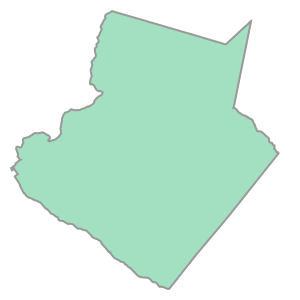

In [88]:
us_migpuma.iloc[1000]["geometry"]

/home/yianzhang/work/research/migration/migration/.pixi/envs/default/lib/python3.9/site-packages/geopandas/geodataframe.py:1750: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  result = super().__getitem__(key)


<Axes: >

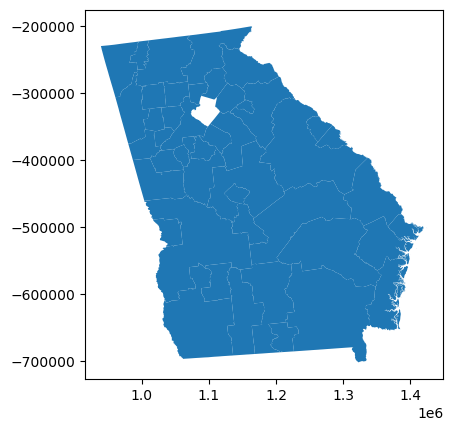

In [89]:
us_migpuma.drop(1000)[us_migpuma["State"] == "Georgia"].plot()

In [90]:
us_migpuma.drop("geometry", axis=1).to_csv(f"migpuma_density_{YEAR}.csv")